Applying complex functions on raster data

In [1]:
import numpy as np
import rasterio 
import matplotlib.pyplot as plt
from rasterio.plot import show

In [2]:
raster_path = 'combined_raster.tif'

In [4]:
threshold = 1000

In [5]:
with rasterio.open(raster_path) as src:
    band1 = src.read(1).astype(float)
    band2 = src.read(2).astype(float)

    elevation_mask = band2 > threshold

    filtered_population = np.where(elevation_mask, band1, 0)
    total_popultion_sum = np.sum(filtered_population)
    print('Population above threshold: ', total_popultion_sum)

Population above threshold:  25294.160665121042


In [7]:
def count_population_above_threshold(threshold):
    raster_path = 'combined_raster.tif'
    
    with rasterio.open(raster_path) as src:
        band1 = src.read(1).astype(float)
        band2 = src.read(2).astype(float)
        elevation_mask = band2 > threshold
        filtered_population = np.where(elevation_mask, band1, 0)
        total_popultion_sum = np.sum(filtered_population)
        return total_popultion_sum

In [8]:
count_population_above_threshold(threshold)

25294.160665121042

In [10]:
thresholds = np.arange(0, 3000, 250)
thresholds

array([   0,  250,  500,  750, 1000, 1250, 1500, 1750, 2000, 2250, 2500,
       2750])

In [11]:
populations = [count_population_above_threshold(threshold) for threshold in thresholds]

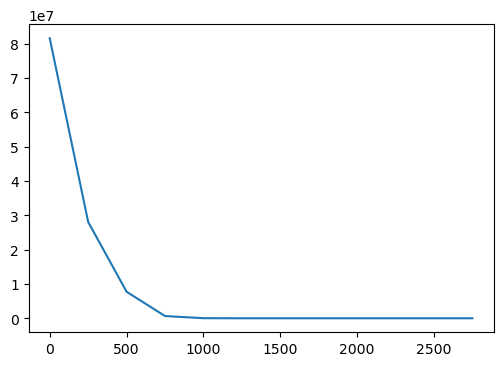

In [12]:
f, ax = plt.subplots(1,1, figsize =(6,4))
plt.plot(thresholds, populations)